In [1]:
# ===========================================================================
# Project : TEXT SENTIMENTS ANALYSIS USING DEEP LEARNING (LSTM + EMBEDDING)
# ===========================================================================

# What this project does :-
# - Takes a movie review (text) as input
# - Predicts wether the sentiment is POSITIVE or NEGATIVE
# - Uses the IMDB dataSEt(50,000 real movie reviews)
# - Build aDeep learning model using LSTM(Long Short-Term Memory)


# DATASET :- IMBD moive reviews (built into keras)
# - 25,000 training reviews
# - 25,000 testing reviews
# - Each review is Labeld :- 1 = Positive , 0 = Negative




In [2]:
!pip install tensorflow


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # handle all the maths behind neural network (forward pass, backword pass, gradinet)


from tensorflow.keras.datasets import imdb
# keras -> high level APi built on top of tensorflow (easier to use )

from tensorflow.keras.preprocessing.sequence import pad_sequences
# sequences -> use to handle sequence data like (text)
# pad_sequence -> make all  sequence the SAME length by adding zero (Neural networks need fixed - sized inputs)

# EXAMPLE:-
# Before: [[1,2,3], [4,5], [6,7,8,9]]   ← different lengths!
# After:  [[1,2,3], [0,4,5], [6,7,8,9]] ← same length (padded with 0)


from tensorflow.keras.models import Sequential
# sequentail -> A linear stack of layers (L1 -> L2 -> L3) Data flows in one ways
#               input -> hidden layer -> output



from tensorflow.keras.layers import (
    Embedding,   # Converts word indices (integers) → dense vectors (meaningful numbers)
    LSTM,        # Long Short-Term Memory - remembers long-term patterns in sequences
    Dense,       # Fully Connected layer - every neuron connects to every neuron in next layer
    Dropout      # Regularization technique - randomly turns OFF neurons during training
                 # to prevent OVERFITTING (memorizing training data)
)

from tensorflow.keras.callbacks import EarlyStopping
# callbacks -> fucntion that run at specfic points during traning
# EarlyStopping -> stops training when model stop improving this saves time and prevents overfitting

In [4]:
# Set hyperparameters

VOCAB_SIZE = 10000
# how many unique words wee keep
# we will only keep most frequent words ( top 10k)

MAX_LENGTH = 200
# maximum number of words per review we consider
# review shorter than 200 words -> padded wiht zeros
# review greatter that 200 words -> truncated (cut) to 200 words

EMBEDDING_DIM = 128
# embedding dimensions == size of the word vector
# each words is converted to a vector of 128 vector
# these 128 number capture the meaning of the words
# Example: "king"  → [0.2, -0.5, 0.8, ... 128 numbers]
#          "queen" → [0.2, -0.4, 0.9, ... 128 numbers]  ← similar to "king"!

LSTM_UNITS = 64
# number of memory cell in th LSTM layer
# more units == more capacity to learn but slower learning

DROPOUT_RATE = 0.5
# fraction of neurons randomly turned off during traning
# 0.5 means 50% pf neurons are randomly disable each traning step
# this help model not to rely on any single neurons -> better generalization
# example :- studying without your notes forces you to Trull understand


BATCH_SIZE = 64
# number of review processed at once before updating weights

# example :-
# like grading a 64 essays, the giving feadback, then grading next 64

EPOCHS = 10
# number of time the model sees the entire traning dataset
# 1 epoch = model has seen all 25000 training reviews once



In [5]:
(x_train, y_train),(x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print(f"\n📊 DATASET SHAPE:")
print(f"  Training samples  : {len(x_train):,}")
print(f"  Test samples      : {len(x_test):,}")
print(f"  Training labels   : {len(y_train):,}")
print(f"  Test labels       : {len(y_test):,}")



📊 DATASET SHAPE:
  Training samples  : 25,000
  Test samples      : 25,000
  Training labels   : 25,000
  Test labels       : 25,000


In [7]:
# Let's look at what one review looks like (before processing)
print(f"\n🔍 SAMPLE REVIEW (raw - as integer indices):")
print(f"  First review (first 10 words): {x_train[0][:10]}")

# the text has been converted into INTEGRES


🔍 SAMPLE REVIEW (raw - as integer indices):
  First review (first 10 words): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


In [8]:
print(f"\n  First review length  : {len(x_train[0])} words")
print(f"  Second review length : {len(x_train[1])} words")
print(f"  Third review length  : {len(x_train[2])} words")

# different lengths we need to fic this -> padding (done next)



  First review length  : 218 words
  Second review length : 189 words
  Third review length  : 141 words


In [9]:

print(f"\n  Label for review 0  : {y_train[0]} ({'Positive' if y_train[0]==1 else 'Negative'})")
print(f"  Label for review 1  : {y_train[1]} ({'Positive' if y_train[1]==1 else 'Negative'})")


  Label for review 0  : 1 (Positive)
  Label for review 1  : 0 (Negative)


In [10]:
# count positive vs negative in traning set

pos_count = np.sum(y_train == 1)
neg_count = np.sum(y_train == 0)

print(f"\n  CLASS DISTRIBUTION (training):")
print(f"  Positive reviews: {pos_count:,} ({pos_count/len(y_train)*100:.1f}%)")
print(f"  Negative reviews: {neg_count:,} ({neg_count/len(y_train)*100:.1f}%)")
# Perfectly balanced! 50% each. No class imbalance problem here.



  CLASS DISTRIBUTION (training):
  Positive reviews: 12,500 (50.0%)
  Negative reviews: 12,500 (50.0%)


In [11]:
# DATA PREPROCESSING - PAD SEQUENCE

x_train_padded = pad_sequences(
    x_train,                # input : list of variable - length sequence
    maxlen = MAX_LENGTH,    # Traget length -> 200 words
    padding = 'pre',        # add zeros at the begining ( before the review)
    truncating = 'pre'      # if too long , cut the begining ( keep endd og review)
     )


x_test_padded = pad_sequences(
    x_test,
    maxlen = MAX_LENGTH,
    padding = 'pre',
    truncating = 'pre'
    )

# shape ->> (25000, 200)
# 25000 reviews , each exactly 200 worfs long
# this is a 2D array (matrix : rows -> reviews, columns -> words)



In [ ]:
# BUILD THE DEEP LEARNING MODEL

# MODEL ARCHITECTURE

# INPUT     -> [64,200]      -> 64 reviews , each 200 words- indices
#   ↓
# EMBEDDING -> [64,200,128]  -> each word index become a 128- dim
#   ↓
# LSTM      -> [64,64]        -> Reades the sequence , output memory values
#   ↓
# DROPOUT   -> [64,64]        -> Randomly zeros 50% of values ( regularization)
#   ↓
# DENSE     -> [64, 1]        -> single output neuron ( probability 0 to 1)
#   ↓
# OUTPUT    -> 0.85            -> posiive (>0.5 == postive , <0.5 == neagtive)

In [12]:
# Now lets build a neural network

model = Sequential()
# Sequential → Creates an empty model where layers are added one by one in order
# Like building a pipeline: each layer's output becomes the next layer's input


model.add(Embedding(
    input_dim = VOCAB_SIZE,
    output_dim = EMBEDDING_DIM,
    input_length = MAX_LENGTH,
))

# WHAT IS EMBEDDING?
#   - Converts sparse integer indices into dense continuous vectors
#   - Before: word "film" = index 25  (just a number, no meaning)
#   - After:  word "film" = [0.2, -0.5, 0.8, 0.1, ... ] (128 meaningful numbers)
#
# WHY EMBEDDING?
#   - Word index 25 ("film") and index 26 ("movie") are SIMILAR words
#   - But numbers 25 and 26 don't capture that similarity
#   - Embedding LEARNS to place similar words CLOSE in vector space
#   - "film" and "movie" will have similar 128-dim vectors
#
# INTERNALLY: Creates a matrix of shape (10000, 128)
#   - 10,000 rows (one per word)
#   - 128 columns (one per dimension)
#   - The model LEARNS the values in this matrix during training!
#
# OUTPUT SHAPE: (batch_size, 200, 128)
#   - 200 words per review
#   - Each word is now a 128-dimensional vector



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
# LSTM LAYER


model.add(LSTM(
    units = LSTM_UNITS,  # number of LSTM memory cells
    dropout = 0.2,       # 20% dropout on IMPUT connection
    recurrent_dropout = 0.2  # 20% dropout on RECURRENT connections(memory connections)
))

# WHAT IS LSTM?
#   - LSTM = Long Short-Term Memory
#   - A special type of Recurrent Neural Network (RNN)
#   - Designed to REMEMBER LONG-TERM PATTERNS in sequences
#
# WHY NOT A SIMPLE RNN?
#   - Vanilla RNN suffers from "Vanishing Gradient Problem"
#   - Gradients shrink to 0 as they flow back through many time steps
#   - It "forgets" what it read at the beginning of a long sequence
#   - LSTM solves this with GATES (learned mechanisms to remember/forget)
#
# HOW LSTM WORKS (conceptually):
#   For each word in the review (200 words):
#     1. FORGET GATE  → Decides what to FORGET from previous memory
#     2. INPUT GATE   → Decides what NEW information to STORE
#     3. OUTPUT GATE  → Decides what to OUTPUT based on memory
#
#   After reading all 200 words, it outputs a summary vector of size 64
#   This 64-dim vector represents "what the model understood about the review"
#
# ANALOGY:
#   Reading "This movie was absolutely terrible and I hated every moment"
#   LSTM remembers "terrible" and "hated" even after reading the full sentence
#   A simple RNN would forget "terrible" by the time it reads "moment"
#
# OUTPUT SHAPE: (batch_size, 64)
#   - One 64-dimensional vector PER REVIEW (not per word anymore)

In [14]:
# DROP OUT LAYER


model.add(Dropout(rate=DROPOUT_RATE)) # rate 0.5 -> 50% neurons randomly turned off

# WHAT IS DROPOUT?
# - During traning :- randomly sets 50% of neuron outpus to zero
# - During testing/ inference :- all neurons are active ( but scaled down)

# WHY DROPOUT?
# - prevent overfitting ( model memorizing training data)
# - forces the network to learn redudanr represtations
# - multiple nuerons learn to detect the same feature
# - if one is dropped, other still make prediction



In [15]:
model.add(Dense(
    units=1 ,
    activation ='sigmoid'   # 1 output nueron (binary: positive or negative )
))
# WHAT IS DENSE LAYER?
#   - Also called "Fully Connected Layer"
#   - Every neuron in this layer is connected to EVERY neuron in the previous layer
#   - Takes the 64 LSTM values → produces 1 probability value
#
# WHAT IS SIGMOID ACTIVATION?
#   - Mathematical formula: sigmoid(x) = 1 / (1 + e^(-x))
#   - Takes ANY number as input
#   - Always outputs a number between 0 and 1
#   - Output interpretation:
#       → 0.0 to 0.5 = NEGATIVE sentiment (closer to 0 = more negative)
#       → 0.5 to 1.0 = POSITIVE sentiment (closer to 1 = more positive)
#   - Example: output = 0.87 → 87% confident it's POSITIVE
#
# WHY SIGMOID FOR BINARY CLASSIFICATION?
#   - Binary = 2 classes (positive or negative)
#   - Sigmoid output = probability of being in class 1 (positive)
#   - 1 - sigmoid = probability of being in class 0 (negative)
#   - If output > 0.5 → predict POSITIVE, else predict NEGATIVE


print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
# compile th model

model.compile(
    optimizer ="adam",


# Optimizer = algortihm that update the weights  to reduce error
# adam = adaptive moment Estimation - most popular optimizer

# HOE OPTIMIZER WORKS
# - model makes a prediction
# - compare with true label -> calculate loss (error)
# - compute Dradietn (which direction to change each weight )
# - update weigths : weigths -lwarning rate * gradient
# - repeat for  batches


# WHY ADAM ?
# - adapts the learning rate for rach parametyer indivisually
# - combines advantage of two optimizers(RMSprop + Momentum)
# - works wekk without much tuning
# - faster convegence than basic gradient descent


    loss= "binary_crossentropy",

  # LOSS FUNCTION -> we measure how worng the model is
  # binary crossentropy is used for binary classification probalility

# Binary Crossentropy is used for BINARY CLASSIFICATION (2 classes)
    #
    # FORMULA: Loss = -[y * log(ŷ) + (1-y) * log(1-ŷ)]
    #   Where: y = true label (0 or 1), ŷ = predicted probability
    #
    # INTUITION:
    #   - True label = 1 (Positive), Model predicts 0.9 → Low loss (good!)
    #   - True label = 1 (Positive), Model predicts 0.1 → High loss (bad!)
    #   - The model is PUNISHED more for confident wrong predictions

    metrics=['accuracy']
     # METRICS = What to track and display during training (doesn't affect training)
    # accuracy = (correct predictions) / (total predictions) * 100
    # This is what we report to humans to understand performance


)


print("\n MOdel compiled sucessfully")



 MOdel compiled sucessfully


In [19]:
# SET up callback

early_stopping = EarlyStopping(
    monitor ='val_loss' ,    # WATCH the validation loss (not training loss)
    # val_loss = loss on data the model has NEVER seen during training
    # We watch this because it shows real generalization, not memorization


  patience = 3,        # wait fro three epocjhs wiht no improveemnt before stopping

    # If val_loss dosen't decrease fro 3 consecutive epochs -> Stop
    # this prevents wasting time traning a model thats's no longer improving


    restore_best_weights = True

    # when traning stops, RESTORE the weight from th BEST epoch
    # (not the last epoch , which might be sightly worse)
)

In [21]:
history = model.fit(
    x_train_padded,   # INPUT: padded training reviews (shape: 25000 x 200)
    y_train,          # LABELS: training labels (25000 values of 0 or 1)

    epochs=EPOCHS,    # Maximum number of passes through entire training data
    # Each EPOCH:
    #   → Model sees all 25,000 training reviews
    #   → Divided into batches of 64
    #   → 25000/64 ≈ 391 batch updates per epoch

    batch_size=BATCH_SIZE,  # Process 64 reviews at once before updating weights

    validation_split=0.2,
    # validation_split=0.2 → Use 20% of training data for validation
    # So: 80% = 20,000 reviews for actual training
    #     20% = 5,000  reviews for validation (checking generalization)
    # VALIDATION DATA IS NEVER USED TO UPDATE WEIGHTS
    # It's only used to EVALUATE how well the model generalizes

    callbacks=[early_stopping],
    # Apply our early stopping callback during training

    verbose=1
    # verbose=1 → Show progress bar and metrics after each epoch
    # verbose=0 → Silent (no output)
    # verbose=2 → One line per epoch (no progress bar)
)

# history = Object that stores metrics at each epoch
# history.history = Dictionary with keys:
#   'loss'     → Training loss per epoch
#   'accuracy' → Training accuracy per epoch
#   'val_loss' → Validation loss per epoch
#   'val_accuracy' → Validation accuracy per epoch



print("\n EVALUATING ON TEST DATA...")
test_loss, test_accuracy = model.evaluate(
    x_test_padded,  # Test features (25,000 reviews)
    y_test,         # True test labels
    verbose=0       # Silent evaluation
)

print(f"\n FINAL TEST RESULTS:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 345ms/step - accuracy: 0.8864 - loss: 0.2884 - val_accuracy: 0.8510 - val_loss: 0.3786
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 112s 358ms/step - accuracy: 0.9006 - loss: 0.2608 - val_accuracy: 0.8450 - val_loss: 0.3801
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 344ms/step - accuracy: 0.9026 - loss: 0.2586 - val_accuracy: 0.8450 - val_loss: 0.4182
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 346ms/step - accuracy: 0.9261 - loss: 0.1979 - val_accuracy: 0.8498 - val_loss: 0.4330

 EVALUATING ON TEST DATA...

 FINAL TEST RESULTS:
   Test Loss     : 0.3891
   Test Accuracy : 0.8462 (84.62%)


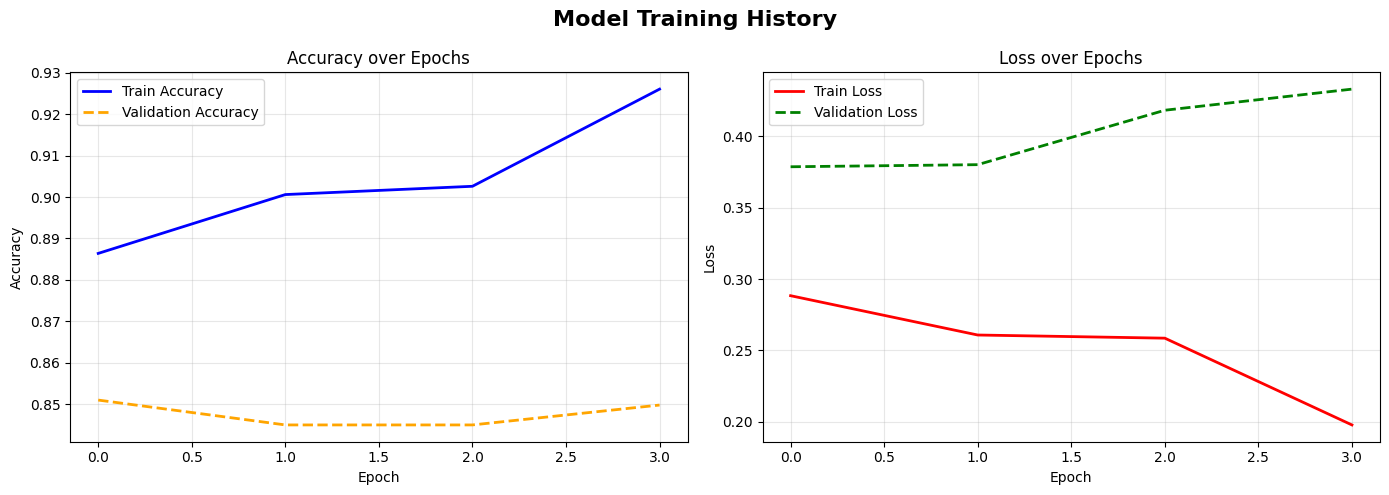

📈 Training history plot saved as 'training_history.png'


In [22]:

def plot_training_history(history):
    """
    Creates two plots:
    1. Training vs Validation ACCURACY over epochs
    2. Training vs Validation LOSS over epochs
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Model Training History", fontsize=16, fontweight='bold')

    # --- PLOT 1: ACCURACY ---
    ax1 = axes[0]
    ax1.plot(history.history['accuracy'],     label='Train Accuracy',      color='blue',   linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2, linestyle='--')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # alpha=0.3 → 30% opacity (semi-transparent grid lines)

    # --- PLOT 2: LOSS ---
    ax2 = axes[1]
    ax2.plot(history.history['loss'],     label='Train Loss',      color='red',   linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='green', linewidth=2, linestyle='--')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    # tight_layout() → Automatically adjusts spacing so subplots don't overlap
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📈 Training history plot saved as 'training_history.png'")

plot_training_history(history)